## Car Damage Severity Classification

This notebook implements a deep learning pipeline based on the DINOv3 ConvNeXt-Small backbone to classify car damage severity into minor, moderate, and severe. The dataset is made by Prajwal Bhamere and comes from https://www.kaggle.com/datasets/prajwalbhamere/car-damage-severity-dataset/data.

### Dependencies

In [11]:
import torch
from torch import nn
from torch.optim import AdamW
from torchvision import transforms
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor, AutoModel
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import numpy as np
import os

In [12]:
pretrained_model_name = "facebook/dinov3-convnext-small-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
base_model = AutoModel.from_pretrained(
    pretrained_model_name, 
    device_map="cuda", 
)

## Wrapper Module
Let's make a wrapper module to wrap the original model so we can expose our own forward method to return just the logits

In [13]:
class CarDamageClassifier(nn.Module):
    def __init__(self, backbone, feature_dim: int = 768, hidden_dim: int = 128, dropout: float = 0.5):
        """
        Creates a torch.nn.Module for our car damage classifier.
        
        Parameters:
            feature_dim: int = 768 - Dimension of the input feature (DINOv3-ConvNext is 768)
            hidden_dim: int = 128 - Hidden layer dimensions (reduced to prevent overfitting)
            dropout: float = 0.5 - Dropout Rate (increased for regularization)
        """
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),  # Normalize features before classification
            nn.Dropout(dropout),
            nn.Linear(feature_dim, hidden_dim),
            nn.GELU(),  # GELU often works better than ReLU
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 3),
        )

    def forward(self, images):
        features = self.backbone(images).pooler_output
        logits = self.head(features)
        return logits

In [14]:
model = CarDamageClassifier(base_model, feature_dim=768, hidden_dim=128, dropout=0.5)
for p in model.backbone.parameters():
    p.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CarDamageClassifier(
  (backbone): DINOv3ConvNextModel(
    (stages): ModuleList(
      (0): DINOv3ConvNextStage(
        (downsample_layers): ModuleList(
          (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
          (1): DINOv3ConvNextLayerNorm((96,), eps=1e-06, elementwise_affine=True)
        )
        (layers): ModuleList(
          (0-2): 3 x DINOv3ConvNextLayer(
            (depthwise_conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (layer_norm): DINOv3ConvNextLayerNorm((96,), eps=1e-06, elementwise_affine=True)
            (pointwise_conv1): Linear(in_features=96, out_features=384, bias=True)
            (activation_fn): GELUActivation()
            (pointwise_conv2): Linear(in_features=384, out_features=96, bias=True)
            (drop_path): Identity()
          )
        )
      )
      (1): DINOv3ConvNextStage(
        (downsample_layers): ModuleList(
          (0): DINOv3ConvNextLayerNorm((96,), eps=1e-06, elementwi

## Data Loading
Let's load our data in and apply some augmentations

### Augmentations

First, let's decide which augmentations we actually need.

For both training and validation, we'll resize to 256x256.

For training, we’ll choose a more aggressive approach.

* Random Horizontal Flips
* Color Jitter (brightness, contrast, saturation, hue) so it doesn’t overfit to a specific lighting.
* Mild Gaussian blur or small rotations to simulate motion blur / slight camera tilt.
* Normalization using Imagenet mean and standard deviation, matching what was used to pretrain the DINOv3 ConvNeXt backbone.

For validation, there are no augmentations.


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

### Data Loading
Now, we can use torch's `ImageFolder` to load our data in and automatically apply augmentations

In [16]:
train_dataset = ImageFolder("../dataset/train", transform=train_transform)
val_dataset   = ImageFolder("../dataset/val",   transform=val_transform)

### Training Configuration


Now we can shift to training our model. We need to configure some of the training constants.

In [ ]:
epochs = 50
batch_size = 32
learning_rate = 5e-4
weight_decay = 0.05
label_smoothing = 0.1

optimizer = AdamW(params=model.head.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss = CrossEntropyLoss(label_smoothing=label_smoothing)

In [18]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=4)

Now we can train the model!

Validation Epoch 1/50: 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]


✓ New best val loss (0.9123): model saved!
Epoch [1/50] Train Loss: 1.0607 | Train Acc: 0.4432 | Val Loss: 0.9123 | Val Acc: 0.6290 | LR: 5.00e-04


Validation Epoch 2/50: 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]


✓ New best val loss (0.8471): model saved!
Epoch [2/50] Train Loss: 0.9627 | Train Acc: 0.5539 | Val Loss: 0.8471 | Val Acc: 0.6855 | LR: 5.00e-04


Validation Epoch 3/50: 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]


...

Epoch [24/50] Train Loss: 0.7605 | Train Acc: 0.7101 | Val Loss: 0.7717 | Val Acc: 0.7177 | LR: 2.50e-04


Validation Epoch 25/50: 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]


Epoch [25/50] Train Loss: 0.7586 | Train Acc: 0.7187 | Val Loss: 0.7712 | Val Acc: 0.7137 | LR: 2.50e-04


Validation Epoch 26/50: 100%|██████████| 8/8 [00:03<00:00,  2.44it/s]

Epoch [26/50] Train Loss: 0.7668 | Train Acc: 0.7093 | Val Loss: 0.7729 | Val Acc: 0.7177 | LR: 2.50e-04

⚠ Early stopping triggered! No improvement for 10 epochs.
  Best validation loss: 0.7599 (at epoch 16)


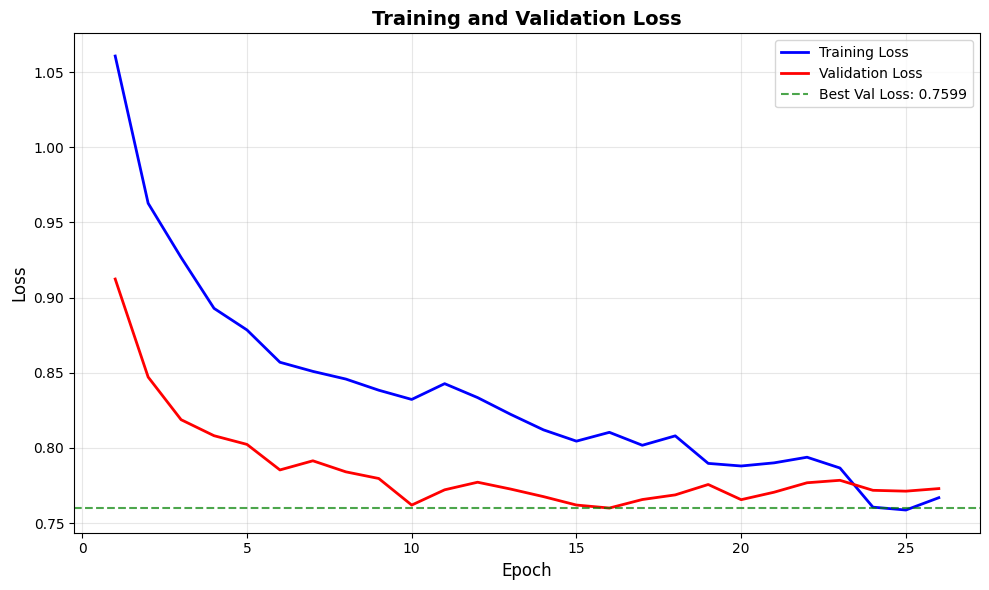

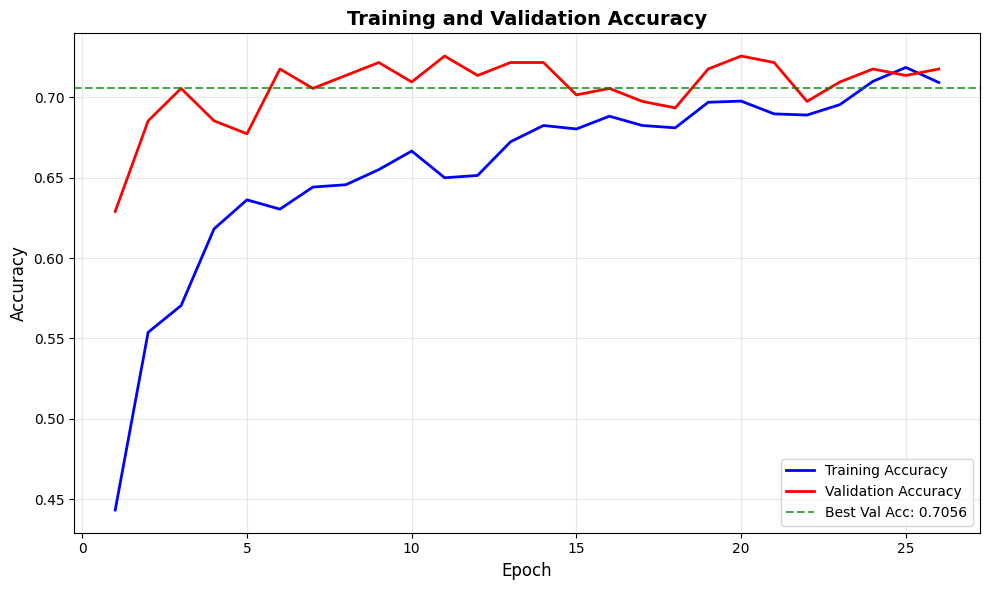

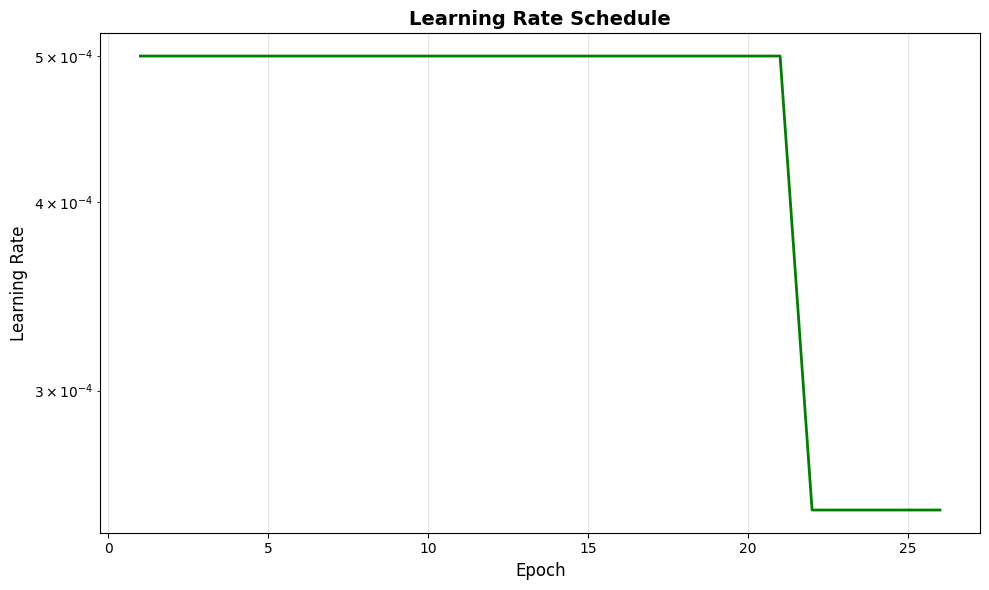


Training Complete!
Best Validation Loss: 0.7599
Best Validation Accuracy: 0.7056
Total Epochs Trained: 26
Final Training Loss: 0.7668
Final Training Accuracy: 0.7093
Final Validation Loss: 0.7729
Final Validation Accuracy: 0.7177


In [ ]:
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

early_stopping_patience = 10
epochs_without_improvement = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss = np.inf
best_val_acc = 0.0

for epoch in range(epochs):
    train_loss = 0.0
    correct = 0
    total = 0

    model.train()

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        computed_loss = loss(logits, labels)

        computed_loss.backward()
        optimizer.step()

        train_loss += computed_loss.item() * images.size(0)
        _, preds = torch.max(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = train_loss / total
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            computed_loss = loss(logits, labels)

            val_loss += computed_loss.item() * images.size(0)
            _, preds = torch.max(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / val_total
    val_acc = val_correct / val_total
    
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    save_dir = f"checkpoints/e{epochs}_b{batch_size}_lr{learning_rate}"

    improved = False
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0
        improved = True
        
        os.makedirs(save_dir, exist_ok=True)
        torch.save(model.state_dict(), f"{save_dir}/best_model.pt")
        print(f"✓ New best val loss ({best_val_loss:.4f}): model saved!")
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} "
        f"| LR: {current_lr:.2e}"
    )
    
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⚠ Early stopping triggered! No improvement for {early_stopping_patience} epochs.")
        print(f"  Best validation loss: {best_val_loss:.4f} (at epoch {epoch + 1 - early_stopping_patience})")
        break

In [ ]:
# Plot 1: Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
plt.axhline(y=best_val_loss, color='g', linestyle='--', alpha=0.7, label=f'Best Val Loss: {best_val_loss:.4f}')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
plt.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.7, label=f'Best Val Acc: {best_val_acc:.4f}')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Learning Rate
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['lr'], 'g-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final statistics
print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Total Epochs Trained: {len(history['train_loss'])}")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Validation Accuracy: {history['val_acc'][-1]:.4f}")
print("="*60)

## Inference

Now let's use our trained model to make predictions on new images.

In [20]:
# Load the best model checkpoint
checkpoint_path = f"checkpoints/e{epochs}_b{batch_size}_lr{learning_rate}/best_model.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

print(f"Loaded best model from {checkpoint_path}")

Loaded best model from checkpoints/e50_b32_lr0.0005/best_model.pt


In [21]:
# Class names (adjust based on your dataset folder structure)
class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['minor', 'moderate', 'severe']


In [22]:
from PIL import Image

def predict_image(image_path, model, transform, class_names, device):
    """
    Predict the class of a single image.
    
    Args:
        image_path: Path to the image file
        model: Trained model
        transform: Image preprocessing transform
        class_names: List of class names
        device: Device to run inference on
    
    Returns:
        predicted_class: Predicted class name
        confidence: Confidence score (probability) for the predicted class
        all_probs: Probabilities for all classes
    """
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Perform inference
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)
        confidence, predicted_idx = torch.max(probs, dim=1)
    
    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item()
    all_probs = probs.squeeze().cpu().numpy()
    
    return predicted_class, confidence, all_probs

### Example: Predict a Single Image

In [23]:
#0020.jpeg minor
#0012.jpeg moderate
#0019.jpeg severe

# Example: Predict on a single image
# Replace this path with your own test image
test_image_path = "../dataset/val/minor/0020.jpeg"  # Update this path

predicted_class, confidence, all_probs = predict_image(
    test_image_path, 
    model, 
    val_transform, 
    class_names, 
    device
)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"\nAll probabilities:")
for class_name, prob in zip(class_names, all_probs):
    print(f"  {class_name}: {prob:.4f}")

Predicted Class: severe
Confidence: 0.4393

All probabilities:
  minor: 0.1457
  moderate: 0.4150
  severe: 0.4393


## Model Evaluation

Let's evaluate the model's performance using confusion matrices, ROC curves, and Precision-Recall curves.

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

### Collect Predictions on Validation Set

In [28]:
# Collect all predictions and ground truth labels
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating on validation set"):
        images = images.to(device)
        labels = labels.to(device)
        
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        _, preds = torch.max(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(f"Collected {len(all_preds)} predictions")

Evaluating on validation set: 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]

Collected 248 predictions


### Confusion Matrix

<Figure size 800x700 with 0 Axes>

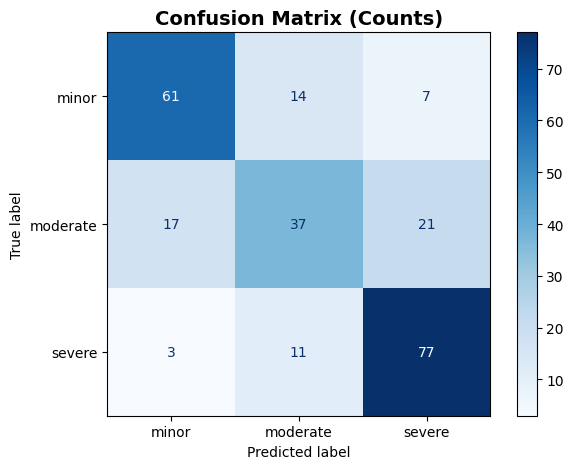


Per-class Accuracy:
  minor: 74.39% (61/82)
  moderate: 49.33% (37/75)
  severe: 84.62% (77/91)


In [29]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class Accuracy:")
for i, class_name in enumerate(class_names):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {class_name}: {class_acc:.2%} ({cm[i, i]}/{cm[i].sum()})")

### ROC Curves (One-vs-Rest)

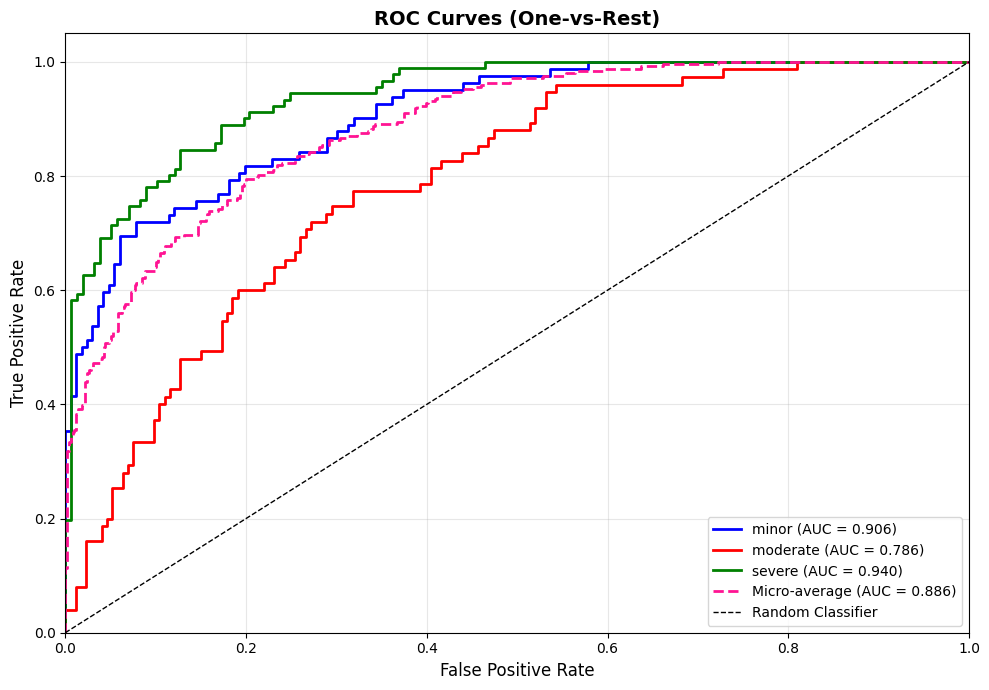


ROC AUC Scores:
  minor: 0.9056
  moderate: 0.7861
  severe: 0.9397
  Micro-average: 0.8860


In [30]:
# Binarize labels for multi-class ROC
n_classes = len(class_names)
y_true_bin = label_binarize(all_labels, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange', 'purple']

# Plot ROC curve for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Plot micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle='--', lw=2,
         label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print AUC scores
print("\nROC AUC Scores:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {roc_auc[i]:.4f}")
print(f"  Micro-average: {roc_auc['micro']:.4f}")

### Precision-Recall Curves

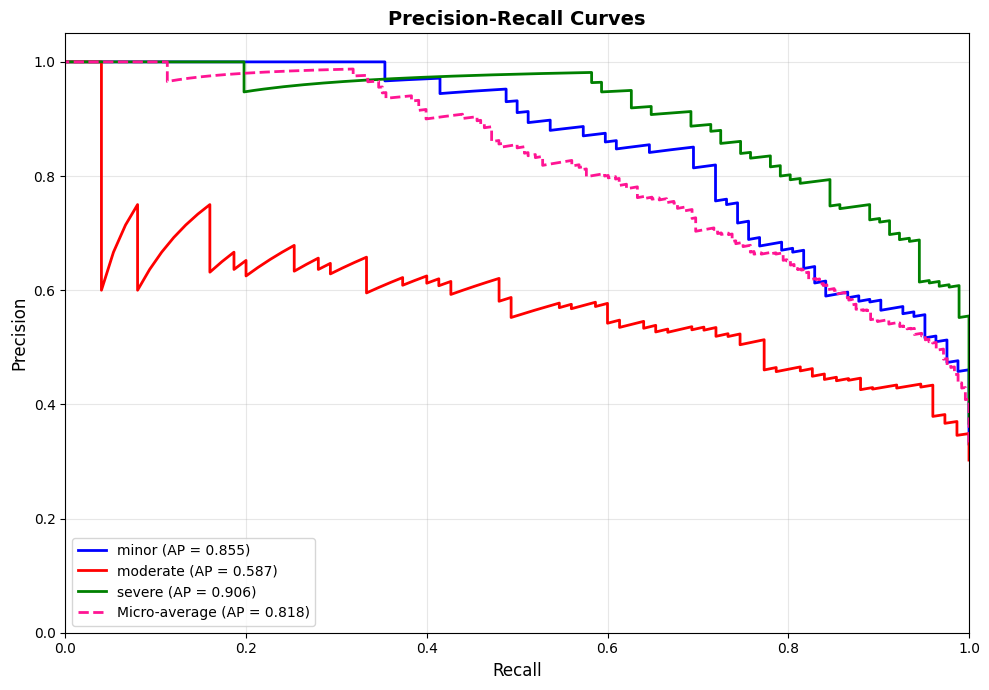


Average Precision Scores:
  minor: 0.8548
  moderate: 0.5867
  severe: 0.9063
  Micro-average: 0.8180


In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

# Compute Precision-Recall curve and Average Precision for each class
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], all_probs[:, i])

# Compute micro-average Precision-Recall curve
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_true_bin.ravel(), all_probs.ravel()
)
average_precision["micro"] = average_precision_score(y_true_bin, all_probs, average="micro")

# Plot Precision-Recall curves
plt.figure(figsize=(10, 7))

# Plot PR curve for each class
for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'{class_names[i]} (AP = {average_precision[i]:.3f})')

# Plot micro-average PR curve
plt.plot(recall["micro"], precision["micro"], color='deeppink', linestyle='--', lw=2,
         label=f'Micro-average (AP = {average_precision["micro"]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print Average Precision scores
print("\nAverage Precision Scores:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {average_precision[i]:.4f}")
print(f"  Micro-average: {average_precision['micro']:.4f}")

### Classification Report

In [32]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("Classification Report:")
print("=" * 60)
print(report)

Classification Report:
              precision    recall  f1-score   support

       minor     0.7531    0.7439    0.7485        82
    moderate     0.5968    0.4933    0.5401        75
      severe     0.7333    0.8462    0.7857        91

    accuracy                         0.7056       248
   macro avg     0.6944    0.6945    0.6914       248
weighted avg     0.6986    0.7056    0.6991       248



### Overall Performance Summary

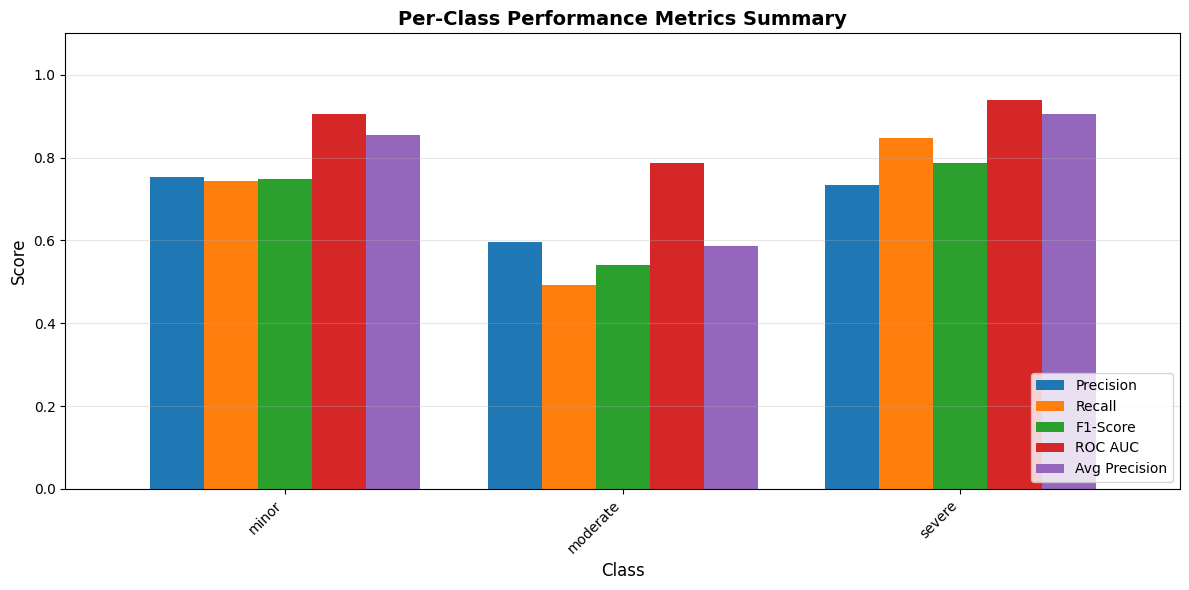


Detailed Metrics by Class:
          Precision    Recall  F1-Score   ROC AUC  Avg Precision
minor      0.753086  0.743902  0.748466  0.905598       0.854829
moderate   0.596774  0.493333  0.540146  0.786050       0.586711
severe     0.733333  0.846154  0.785714  0.939735       0.906323


Overall Metrics:
  Accuracy: 0.7056
  Macro-avg Precision: 0.6944
  Macro-avg Recall: 0.6945
  Macro-avg F1-Score: 0.6914
  Macro-avg ROC AUC: 0.8771
  Macro-avg AP: 0.7826


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate per-class metrics
precisions = precision_score(all_labels, all_preds, average=None)
recalls = recall_score(all_labels, all_preds, average=None)
f1_scores = f1_score(all_labels, all_preds, average=None)

# Create a summary dataframe for visualization
import pandas as pd

metrics_df = pd.DataFrame({
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores,
    'ROC AUC': [roc_auc[i] for i in range(n_classes)],
    'Avg Precision': [average_precision[i] for i in range(n_classes)]
}, index=class_names)

# Plot summary metrics
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_title('Per-Class Performance Metrics Summary', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display metrics table
print("\nDetailed Metrics by Class:")
print("=" * 80)
print(metrics_df.to_string())
print("\n" + "=" * 80)

# Overall metrics
print("\nOverall Metrics:")
print(f"  Accuracy: {(all_preds == all_labels).mean():.4f}")
print(f"  Macro-avg Precision: {precisions.mean():.4f}")
print(f"  Macro-avg Recall: {recalls.mean():.4f}")
print(f"  Macro-avg F1-Score: {f1_scores.mean():.4f}")
print(f"  Macro-avg ROC AUC: {np.mean([roc_auc[i] for i in range(n_classes)]):.4f}")
print(f"  Macro-avg AP: {np.mean([average_precision[i] for i in range(n_classes)]):.4f}")